# FD003 - Pseudo Cluster Experiments

**Advertencia metodologica:** este notebook usa solo `train_FD003.txt` con validacion artificial por motores completos y cortes internos. El test oficial no se utiliza.

Objetivo: evaluar si probabilidades de patrones latentes de degradacion, estimadas sin leakage por un clasificador auxiliar, ayudan a mejorar el modelo FD003 frente al mejor candidato obtenido en tuning/features.

## 1. Setup

Se cargan utilidades del proyecto, se detecta la raiz y se crean las carpetas de salida. Los outputs quedan separados por tipo: CSV en `results/FD003`, figuras en `figures/FD003`, configs en `configs/FD003` y notas en `notas/FD003`.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "CMAPSSData").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.fd003_improvement_utils import (
    FD003_RANDOM_STATES,
    add_rul_bins_to_predictions,
    comparison_row_from_summary,
    config_from_summary_row,
    ensure_fd003_dirs,
    load_json,
    metrics_by_group,
    run_fd003_pseudo_cluster_experiments,
    save_json,
    select_best_summary_row,
    summarize_detail,
)

PATHS = ensure_fd003_dirs(PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / "CMAPSSData"
RESULTS_DIR = PATHS["results"]
FIGURES_DIR = PATHS["figures"]
CONFIGS_DIR = PATHS["configs"]
NOTES_DIR = PATHS["notes"]

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Resultados: {RESULTS_DIR}")
print(f"Random states: {FD003_RANDOM_STATES}")

Proyecto: C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML
Resultados: C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML\results\FD003
Random states: [0, 1, 2, 3, 4]


## 2. Configuracion base

Se usa como punto de partida el mejor candidato ya encontrado en FD003. Si existe la configuracion con features sensibles a patrones, se usa esa porque fue mejor por C-MAPSS; si no existe, se vuelve al mejor tuning corto.

In [2]:
short_config_path = CONFIGS_DIR / "fd003_short_tuning_best_config.json"
fault_config_path = CONFIGS_DIR / "fd003_fault_sensitive_features_best_config.json"

if not short_config_path.exists():
    raise FileNotFoundError(f"Falta config requerida: {short_config_path}")

short_config = load_json(short_config_path)
if fault_config_path.exists():
    baseline_config = load_json(fault_config_path)
    baseline_source = "fd003_fault_sensitive_features_best_config.json"
else:
    baseline_config = short_config
    baseline_source = "fd003_short_tuning_best_config.json"

print("Config base usada:", baseline_source)
print(json.dumps({
    "model_name": baseline_config["model_name"],
    "feature_set": baseline_config.get("feature_set"),
    "window_size": baseline_config["window_size"],
    "rul_cap": baseline_config["rul_cap"],
    "objective": baseline_config["objective"],
    "alpha": baseline_config.get("alpha"),
    "sample_weight_scheme": baseline_config.get("sample_weight_scheme"),
}, indent=2))

Config base usada: fd003_fault_sensitive_features_best_config.json
{
  "model_name": "fd003_lgbm_w50_cap125_quantile_a04_none_fault_sensitive",
  "feature_set": "fault_sensitive",
  "window_size": 50,
  "rul_cap": 125,
  "objective": "quantile",
  "alpha": 0.4,
  "sample_weight_scheme": "none"
}


## 3. Experimentos pseudo-cluster sin leakage

Para cada split se reconstruyen clusters solo con motores de entrenamiento. Luego se entrena un clasificador auxiliar con features disponibles hasta cada ciclo/corte para estimar `cluster_prob_0` y `cluster_prob_1`.

Variantes comparadas:

- `global_baseline`: mismo modelo base sin probabilidades de cluster.
- `global_with_cluster_probs`: mismo modelo agregando probabilidades predichas como features.
- `mixture_of_experts_soft`: dos regresores expertos por cluster de entrenamiento, combinados por probabilidad predicha.

El `cluster_id` verdadero de validacion no se usa como input.

In [3]:
detail, predictions, diagnostics = run_fd003_pseudo_cluster_experiments(
    config=baseline_config,
    data_dir=DATA_DIR,
    random_states=FD003_RANDOM_STATES,
)

summary_group_cols = [
    "variant",
    "model_name",
    "approach",
    "window_size",
    "rul_cap",
    "objective",
    "alpha",
    "sample_weight_scheme",
    "feature_set",
]
summary = summarize_detail(detail, summary_group_cols).sort_values(
    ["mean_cmapss_score", "mean_dangerous_error_pct", "mean_rmse"]
).reset_index(drop=True)

predictions_with_bins = add_rul_bins_to_predictions(predictions)
by_rul_bin = metrics_by_group(predictions_with_bins, ["variant", "rul_bin"])

cluster_file = RESULTS_DIR / "fd003_unit_clusters.csv"
if cluster_file.exists():
    full_clusters = pd.read_csv(cluster_file)
    posthoc = predictions.merge(
        full_clusters[["unit_number", "cluster_id"]],
        on="unit_number",
        how="left",
    )
    by_full_cluster = metrics_by_group(posthoc.dropna(subset=["cluster_id"]), ["variant", "cluster_id"])
    by_full_cluster.to_csv(RESULTS_DIR / "fd003_pseudo_cluster_experiments_by_full_train_cluster.csv", index=False)
else:
    by_full_cluster = pd.DataFrame()

detail.to_csv(RESULTS_DIR / "fd003_pseudo_cluster_experiments_detail.csv", index=False)
summary.to_csv(RESULTS_DIR / "fd003_pseudo_cluster_experiments_summary.csv", index=False)
by_rul_bin.to_csv(RESULTS_DIR / "fd003_pseudo_cluster_experiments_by_rul_bin.csv", index=False)
diagnostics.to_csv(RESULTS_DIR / "fd003_pseudo_cluster_classifier_diagnostics.csv", index=False)
predictions.to_csv(RESULTS_DIR / "fd003_pseudo_cluster_validation_predictions.csv", index=False)

best_pseudo_row = select_best_summary_row(summary)
best_pseudo_config = config_from_summary_row(best_pseudo_row, hyperparameters=baseline_config.get("hyperparameters"))
best_pseudo_config.update({
    "selected_by": "FD003 pseudo-cluster artificial validation",
    "selection_basis": "lowest mean C-MAPSS, then dangerous error and RMSE",
    "validation_protocol": "train_FD003 only, held-out units, artificial cutoffs, multi-split",
    "official_test_used": False,
    "cluster_method_note": "Cluster probabilities are predicted by an auxiliary classifier trained only on train units inside each split. True validation clusters are not used as features.",
    "baseline_config_source": baseline_source,
    "variant": best_pseudo_row["variant"],
    "validation_summary": {k: (None if pd.isna(v) else float(v) if isinstance(v, (int, float, np.floating)) else v) for k, v in best_pseudo_row.items()},
})
save_json(CONFIGS_DIR / "fd003_pseudo_cluster_best_config.json", best_pseudo_config)

print("Resumen pseudo-cluster:")
display(summary)
print("Diagnostico clasificador auxiliar:")
display(diagnostics)

Resumen pseudo-cluster:


,variant,model_name,approach,window_size,rul_cap,objective,alpha,sample_weight_scheme,feature_set,mean_mae,...,std_conservative_error_pct,mean_bias_mean,std_bias_mean,mean_abs_error_p90,std_abs_error_p90,mean_abs_error_p95,std_abs_error_p95,worst_rmse,worst_cmapss_score,worst_dangerous_error_pct
0,global_baseline,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,pseudo_cluster_baseline,50,125,quantile,0.4,none,fault_sensitive,12.162365,...,5.128353,-3.651100,2.863412,28.109534,2.194166,34.689625,3.782988,17.896168,443.161862,8.0
1,global_with_cluster_probs,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,pseudo_cluster_prob_features,50,125,quantile,0.4,none,fault_sensitive,12.282010,...,4.847680,-3.479559,2.775019,27.600771,4.168919,34.370331,3.615690,18.004098,517.055024,9.0
2,mixture_of_experts_soft,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,pseudo_cluster_soft_mixture,50,125,quantile,0.4,none,fault_sensitive,12.468416,...,5.983310,-2.919923,2.880568,27.465151,1.223827,32.984913,3.306016,18.914139,739.822046,10.0


Diagnostico clasificador auxiliar:


,random_state,cluster_classifier_oof_accuracy,n_train_units_cluster_0,n_train_units_cluster_1,n_train_rows_cluster_0,n_train_rows_cluster_1,mean_eval_cluster_prob_0,mean_eval_cluster_prob_1,mixture_fallback
0,0,0.999428,37,43,10500,8803,0.352661,0.647339,False
1,1,0.998086,33,47,10037,9697,0.551886,0.448114,False
2,2,0.999359,42,38,8474,11657,0.696484,0.303516,False
3,3,0.999476,48,32,9706,9515,0.398266,0.601734,False
4,4,0.983038,35,45,10565,9005,0.525023,0.474977,False


## 4. Visuales

Se guardan y se muestran los graficos pedidos para comparar las variantes.

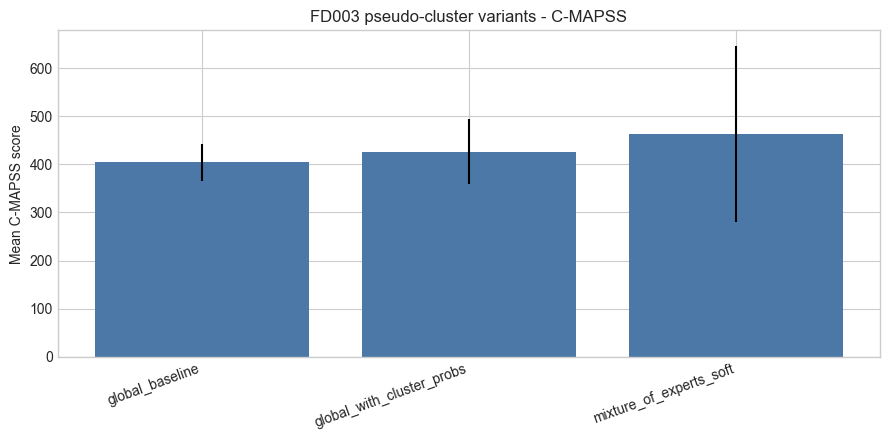

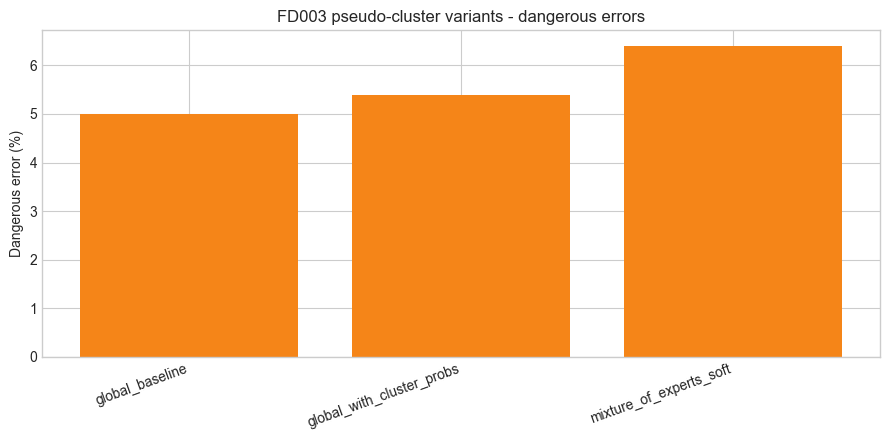

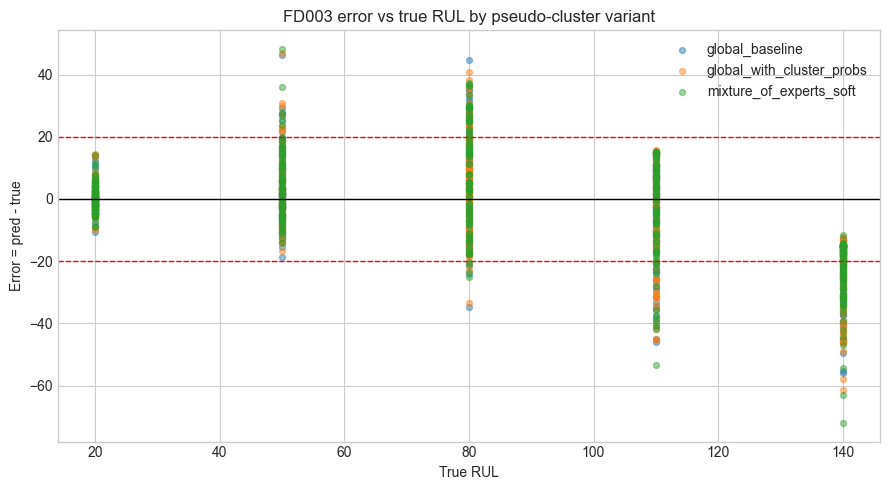

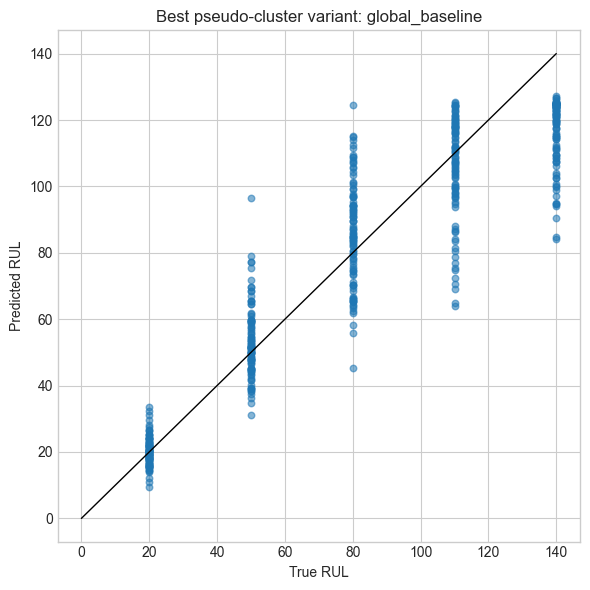

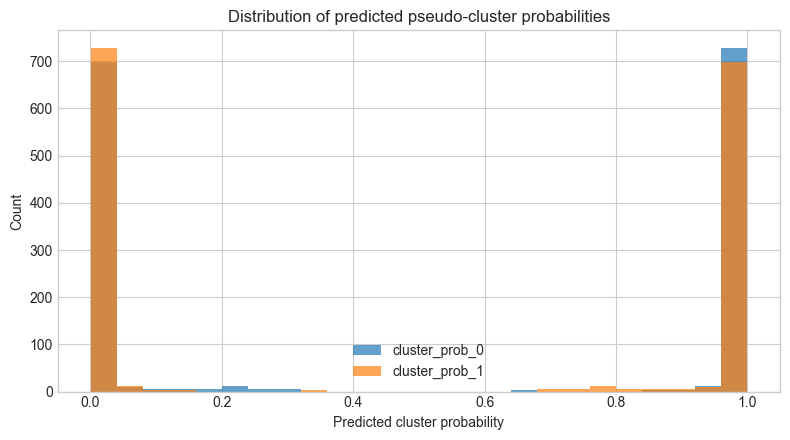

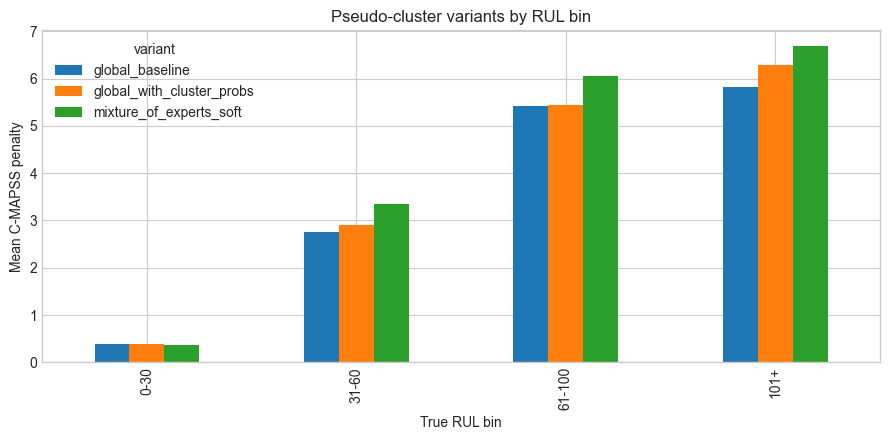

In [4]:
plt.style.use("seaborn-v0_8-whitegrid")

ordered = summary.sort_values("mean_cmapss_score")
labels = ordered["variant"].tolist()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x, ordered["mean_cmapss_score"], yerr=ordered["std_cmapss_score"], color="#4c78a8")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Mean C-MAPSS score")
ax.set_title("FD003 pseudo-cluster variants - C-MAPSS")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd003_pseudo_cluster_variant_comparison_cmapss.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x, ordered["mean_dangerous_error_pct"], color="#f58518")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Dangerous error (%)")
ax.set_title("FD003 pseudo-cluster variants - dangerous errors")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd003_pseudo_cluster_variant_comparison_dangerous.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for variant, group in predictions.groupby("variant"):
    ax.scatter(group["true_rul"], group["error"], s=18, alpha=0.45, label=variant)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(20, color="red", linestyle="--", linewidth=1)
ax.axhline(-20, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("True RUL")
ax.set_ylabel("Error = pred - true")
ax.set_title("FD003 error vs true RUL by pseudo-cluster variant")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd003_pseudo_cluster_error_vs_rul_by_variant.png", dpi=160)
plt.show()

best_variant = best_pseudo_row["variant"]
best_predictions = predictions.loc[predictions["variant"] == best_variant]
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(best_predictions["true_rul"], best_predictions["pred_rul"], s=22, alpha=0.55)
max_axis = max(best_predictions["true_rul"].max(), best_predictions["pred_rul"].max())
ax.plot([0, max_axis], [0, max_axis], color="black", linewidth=1)
ax.set_xlabel("True RUL")
ax.set_ylabel("Predicted RUL")
ax.set_title(f"Best pseudo-cluster variant: {best_variant}")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd003_pseudo_cluster_pred_vs_true_best_variant.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(predictions["cluster_prob_0"], bins=25, alpha=0.7, label="cluster_prob_0")
ax.hist(predictions["cluster_prob_1"], bins=25, alpha=0.7, label="cluster_prob_1")
ax.set_xlabel("Predicted cluster probability")
ax.set_ylabel("Count")
ax.set_title("Distribution of predicted pseudo-cluster probabilities")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd003_pseudo_cluster_probs_distribution.png", dpi=160)
plt.show()

plot_bin = by_rul_bin.copy()
plot_bin["rul_bin"] = plot_bin["rul_bin"].astype(str)
pivot = plot_bin.pivot(index="rul_bin", columns="variant", values="cmapss_score_mean")
fig, ax = plt.subplots(figsize=(9, 4.5))
pivot.loc[[b for b in ["0-30", "31-60", "61-100", "101+"] if b in pivot.index]].plot(kind="bar", ax=ax)
ax.set_ylabel("Mean C-MAPSS penalty")
ax.set_xlabel("True RUL bin")
ax.set_title("Pseudo-cluster variants by RUL bin")
ax.legend(title="variant")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd003_pseudo_cluster_metrics_by_rul_bin.png", dpi=160)
plt.show()

## 5. Interpretacion pseudo-cluster

Se guarda una lectura breve y prudente: estos clusters aproximan patrones latentes, no fault modes reales.

In [5]:
baseline_row = summary.loc[summary["variant"] == "global_baseline"].iloc[0]
prob_row = summary.loc[summary["variant"] == "global_with_cluster_probs"].iloc[0]
mixture_row = summary.loc[summary["variant"] == "mixture_of_experts_soft"].iloc[0]

lines = [
    "FD003 - Experimentos pseudo-cluster sin leakage",
    "",
    "Metodologia:",
    "Se uso solamente train_FD003 con validacion artificial por motores completos y cortes internos.",
    "Los clusters se reconstruyeron dentro de cada split usando solo motores de entrenamiento.",
    "Para validacion no se uso cluster_id verdadero: se usaron probabilidades predichas por un clasificador auxiliar.",
    "Los clusters aproximan patrones latentes de degradacion; no son etiquetas reales de fault mode.",
    "",
    "Resultados promedio multi-split:",
]
for _, row in summary.iterrows():
    lines.append(
        f"- {row['variant']}: C-MAPSS {row['mean_cmapss_score']:.3f}, RMSE {row['mean_rmse']:.3f}, "
        f"dangerous {row['mean_dangerous_error_pct']:.2f}%, conservative {row['mean_conservative_error_pct']:.2f}%, "
        f"bias {row['mean_bias_mean']:.3f}."
    )

prob_delta = prob_row["mean_cmapss_score"] - baseline_row["mean_cmapss_score"]
mixture_delta = mixture_row["mean_cmapss_score"] - baseline_row["mean_cmapss_score"]
best_variant = best_pseudo_row["variant"]

lines.extend([
    "",
    f"Cluster classifier OOF accuracy media: {diagnostics['cluster_classifier_oof_accuracy'].mean():.3f}.",
    f"Cambio C-MAPSS global_with_cluster_probs vs baseline: {prob_delta:.3f}.",
    f"Cambio C-MAPSS mixture_of_experts_soft vs baseline: {mixture_delta:.3f}.",
    "",
])

if best_variant == "global_baseline":
    conclusion = "Las variantes pseudo-cluster no mejoran al baseline global; agregan complejidad sin ganancia suficiente en esta validacion."
elif abs(min(prob_delta, mixture_delta)) < 15:
    conclusion = "La mejor variante pseudo-cluster mejora de forma marginal; conviene tratarla como evidencia exploratoria, no como cambio fuerte de modelo."
else:
    conclusion = "La mejor variante pseudo-cluster mejora C-MAPSS de forma visible, pero debe considerarse el riesgo de varianza y sobreajuste por la capa auxiliar."

mid_bin = by_rul_bin.loc[by_rul_bin["rul_bin"].astype(str) == "61-100"].copy()
if not mid_bin.empty:
    mid_best = mid_bin.sort_values("cmapss_score_mean").iloc[0]
    lines.append(f"En RUL medio 61-100, la menor penalizacion media queda en {mid_best['variant']} ({mid_best['cmapss_score_mean']:.3f}).")

lines.extend(["", conclusion, ""])
(NOTES_DIR / "fd003_pseudo_cluster_experiments_interpretation.txt").write_text("\n".join(lines), encoding="utf-8")
print("\n".join(lines))

FD003 - Experimentos pseudo-cluster sin leakage

Metodologia:
Se uso solamente train_FD003 con validacion artificial por motores completos y cortes internos.
Los clusters se reconstruyeron dentro de cada split usando solo motores de entrenamiento.
Para validacion no se uso cluster_id verdadero: se usaron probabilidades predichas por un clasificador auxiliar.
Los clusters aproximan patrones latentes de degradacion; no son etiquetas reales de fault mode.

Resultados promedio multi-split:
- global_baseline: C-MAPSS 404.182, RMSE 16.367, dangerous 5.00%, conservative 13.60%, bias -3.651.
- global_with_cluster_probs: C-MAPSS 426.584, RMSE 16.608, dangerous 5.40%, conservative 13.00%, bias -3.480.
- mixture_of_experts_soft: C-MAPSS 462.562, RMSE 16.520, dangerous 6.40%, conservative 13.60%, bias -2.920.

Cluster classifier OOF accuracy media: 0.996.
Cambio C-MAPSS global_with_cluster_probs vs baseline: 22.402.
Cambio C-MAPSS mixture_of_experts_soft vs baseline: 58.380.

En RUL medio 61-100, 

## 6. Comparacion global FD003

Se consolidan los resultados de transferencia, tuning corto, features sensibles y pseudo-clusters. La seleccion sigue priorizando C-MAPSS promedio, con dangerous error y RMSE como criterios secundarios.

In [6]:
transfer_summary = pd.read_csv(RESULTS_DIR / "fd003_transfer_fd001_pipeline_validation_summary.csv")
short_summary = pd.read_csv(RESULTS_DIR / "fd003_short_tuning_summary.csv")
fault_summary = pd.read_csv(RESULTS_DIR / "fd003_fault_sensitive_features_summary.csv")

transfer_row = transfer_summary.iloc[0].to_dict()
short_row = short_summary.sort_values(["mean_cmapss_score", "mean_dangerous_error_pct", "mean_rmse"]).iloc[0].to_dict()
fault_row = fault_summary.sort_values(["mean_cmapss_score", "mean_dangerous_error_pct", "mean_rmse"]).iloc[0].to_dict()
prob_row_dict = summary.loc[summary["variant"] == "global_with_cluster_probs"].iloc[0].to_dict()
mixture_row_dict = summary.loc[summary["variant"] == "mixture_of_experts_soft"].iloc[0].to_dict()

comparison_rows = [
    comparison_row_from_summary(transfer_row, "FD001 transfer baseline sobre FD003", "Pipeline FD001 transferido directo a FD003."),
    comparison_row_from_summary(short_row, "FD003 short tuning best", "Mejor punto de la busqueda corta FD003."),
    comparison_row_from_summary(fault_row, "FD003 fault-sensitive features best", "Mismo modelo con features temporales sensibles a patrones."),
    comparison_row_from_summary(prob_row_dict, "FD003 global with cluster probabilities", "Probabilidades de cluster predichas agregadas como features."),
    comparison_row_from_summary(mixture_row_dict, "FD003 mixture of experts soft", "Dos expertos por cluster de entrenamiento combinados por probabilidad predicha."),
]
comparison = pd.DataFrame(comparison_rows)
ranked = comparison.sort_values(["mean_CMAPSS", "mean_dangerous_error_pct", "mean_RMSE"]).reset_index(drop=True)
final_row = ranked.iloc[0].copy()
final_row["approach"] = "mejor variante final"
final_row["notes"] = "Seleccion final interna por menor C-MAPSS promedio, con dangerous error y RMSE como criterios secundarios. No usa test oficial."
comparison = pd.concat([comparison, pd.DataFrame([final_row])], ignore_index=True)
comparison.to_csv(RESULTS_DIR / "fd003_model_improvement_global_comparison.csv", index=False)

final_source = ranked.iloc[0]
final_model_name = final_source["model_name"]
if final_source["approach"] == "FD003 fault-sensitive features best":
    final_config = load_json(CONFIGS_DIR / "fd003_fault_sensitive_features_best_config.json")
elif final_source["approach"] == "FD003 short tuning best":
    final_config = load_json(CONFIGS_DIR / "fd003_short_tuning_best_config.json")
elif "cluster" in final_source["approach"] or "mixture" in final_source["approach"]:
    final_config = load_json(CONFIGS_DIR / "fd003_pseudo_cluster_best_config.json")
else:
    final_config = dict(short_config)
    final_config["model_name"] = final_model_name

final_config.update({
    "selected_as": "FD003 final internal candidate",
    "selected_from": "notebooks/FD003/modeling/23_fd003_pseudo_cluster_experiments.ipynb",
    "selection_basis": "lowest mean C-MAPSS in artificial validation, dangerous error and RMSE as secondary criteria",
    "validation_protocol": "train_FD003 only, held-out units, artificial cutoffs, multi-split",
    "official_test_used": False,
    "official_test_used_for_selection": False,
    "global_comparison_metrics": {k: (None if pd.isna(v) else float(v) if isinstance(v, (int, float, np.floating)) else v) for k, v in final_source.items()},
})
save_json(CONFIGS_DIR / "fd003_final_candidate_config.json", final_config)

lines = [
    "FD003 - Comparacion global de mejoras",
    "",
    "Regla metodologica: no se uso test oficial. Toda la seleccion se hizo con train_FD003, validacion por motores completos y cortes artificiales.",
    "",
    "Resumen:",
]
for _, row in ranked.iterrows():
    lines.append(
        f"- {row['approach']}: {row['model_name']} | C-MAPSS {row['mean_CMAPSS']:.3f}, "
        f"RMSE {row['mean_RMSE']:.3f}, dangerous {row['mean_dangerous_error_pct']:.2f}%, bias {row['mean_bias']:.3f}."
    )

best_approach = ranked.iloc[0]["approach"]
lines.extend([
    "",
    f"Candidato final interno FD003: {ranked.iloc[0]['model_name']} ({best_approach}).",
])

if best_approach == "FD003 fault-sensitive features best":
    lines.append("La mejora mas util vino de agregar features temporales sensibles a patrones de degradacion; el tuning corto solo no supero al transfer baseline y los pseudo-clusters no justificaron complejidad adicional si quedaron por debajo.")
elif "cluster" in best_approach or "mixture" in best_approach:
    lines.append("La mejora mas util vino de aprovechar patrones latentes con probabilidades predichas, sin usar cluster_id verdadero de validacion como feature. Debe controlarse el riesgo de sobreajuste de la capa auxiliar.")
else:
    lines.append("La mejor opcion sigue siendo el modelo global sin mayor complejidad; las extensiones no dieron ganancia suficiente en validacion artificial.")

lines.extend([
    "",
    "Riesgos restantes: los clusters no son etiquetas reales de fault mode, la validacion sigue siendo artificial y el test oficial queda reservado para una evaluacion final futura unica.",
    "",
])
(NOTES_DIR / "fd003_model_improvement_global_interpretation.txt").write_text("\n".join(lines), encoding="utf-8")

print("Comparacion global guardada:", RESULTS_DIR / "fd003_model_improvement_global_comparison.csv")
print("Config final guardada:", CONFIGS_DIR / "fd003_final_candidate_config.json")
display(comparison)
print("\n".join(lines))

Comparacion global guardada: C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML\results\FD003\fd003_model_improvement_global_comparison.csv
Config final guardada: C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML\configs\FD003\fd003_final_candidate_config.json


,model_name,approach,window_size,rul_cap,objective,alpha,sample_weight_scheme,mean_MAE,std_MAE,mean_RMSE,...,mean_R2,std_R2,mean_CMAPSS,std_CMAPSS,mean_dangerous_error_pct,mean_conservative_error_pct,mean_bias,worst_RMSE,worst_CMAPSS,notes
0,candidate_03_B_quantile_a040_search_14,FD001 transfer baseline sobre FD003,50,125,quantile,0.4,none,12.079831,0.690581,16.448624,...,0.848610,0.028931,424.430214,84.284135,5.6,13.4,-3.593095,18.183572,555.049531,Pipeline FD001 transferido directo a FD003.
1,fd003_lgbm_w50_cap125_quantile_a04_none,FD003 short tuning best,50,125,quantile,0.4,none,12.079831,0.690581,16.448624,...,0.848610,0.028931,424.430214,84.284135,5.6,13.4,-3.593095,18.183572,555.049531,Mejor punto de la busqueda corta FD003.
2,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,FD003 fault-sensitive features best,50,125,quantile,0.4,none,12.162365,0.578953,16.367037,...,0.850622,0.020638,404.182338,38.602982,5.0,13.6,-3.651100,17.896168,443.161862,Mismo modelo con features temporales sensibles...
3,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,FD003 global with cluster probabilities,50,125,quantile,0.4,none,12.282010,0.490625,16.608002,...,0.846127,0.022160,426.583952,67.804345,5.4,13.0,-3.479559,18.004098,517.055024,Probabilidades de cluster predichas agregadas ...
4,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,FD003 mixture of experts soft,50,125,quantile,0.4,none,12.468416,1.143260,16.520360,...,0.846809,0.034483,462.562318,183.255336,6.4,13.6,-2.919923,18.914139,739.822046,Dos expertos por cluster de entrenamiento comb...
5,fd003_lgbm_w50_cap125_quantile_a04_none_fault_...,mejor variante final,50,125,quantile,0.4,none,12.162365,0.578953,16.367037,...,0.850622,0.020638,404.182338,38.602982,5.0,13.6,-3.651100,17.896168,443.161862,Seleccion final interna por menor C-MAPSS prom...


FD003 - Comparacion global de mejoras

Regla metodologica: no se uso test oficial. Toda la seleccion se hizo con train_FD003, validacion por motores completos y cortes artificiales.

Resumen:
- FD003 fault-sensitive features best: fd003_lgbm_w50_cap125_quantile_a04_none_fault_sensitive | C-MAPSS 404.182, RMSE 16.367, dangerous 5.00%, bias -3.651.
- FD001 transfer baseline sobre FD003: candidate_03_B_quantile_a040_search_14 | C-MAPSS 424.430, RMSE 16.449, dangerous 5.60%, bias -3.593.
- FD003 short tuning best: fd003_lgbm_w50_cap125_quantile_a04_none | C-MAPSS 424.430, RMSE 16.449, dangerous 5.60%, bias -3.593.
- FD003 global with cluster probabilities: fd003_lgbm_w50_cap125_quantile_a04_none_fault_sensitive_global_with_cluster_probs | C-MAPSS 426.584, RMSE 16.608, dangerous 5.40%, bias -3.480.
- FD003 mixture of experts soft: fd003_lgbm_w50_cap125_quantile_a04_none_fault_sensitive_mixture_of_experts_soft | C-MAPSS 462.562, RMSE 16.520, dangerous 6.40%, bias -2.920.

Candidato final int